# Sector Earnings, Market Structure, and ETF Leadership

**Goal.** Build a professional research note around the cleaned `fundamentals_history` universe, aggregate it into canonical sectors, and test whether lagged sector earnings signals plus market-cap, liquidity, and price context explain next-quarter sector ETF leadership.

**What changed before this notebook:**
- Sector labels are normalized into 11 canonical buckets linked to liquid ETF proxies.
- Ambiguous or non-primary securities such as many preferreds, warrants, units, notes, and shell-company listings are excluded from sector aggregates.
- Surprise and EPS-growth percentages are winsorized after filtering tiny denominators, so a few near-zero EPS estimates no longer dominate the relationship tables.
- The panel model uses **lagged** sector fundamentals to avoid reading same-quarter earnings as if they were known at quarter-end.

**Notebook map**
1. Setup and report loading
2. Cleaning audit and universe coverage
3. Distribution repair after clipping
4. Cleaned sector relationship map
5. Sector market-cap and liquidity structure
6. Panel design and target definition
7. Ensemble model results
8. Feature importance and relationship takeaways
9. Holdout quarter picks
10. Conclusions and caveats

## 1. Setup and report loading

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (11, 4.8),
    'figure.dpi': 115,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ANALYSIS_DIR = PROJECT_ROOT / 'outputs' / 'fundamentals_analysis'
RESEARCH_DIR = PROJECT_ROOT / 'outputs' / 'sector_fundamentals_research'
print('analysis dir:', ANALYSIS_DIR)
print('research dir:', RESEARCH_DIR)

analysis dir: d:\dev\price_action\outputs\fundamentals_analysis
research dir: d:\dev\price_action\outputs\sector_fundamentals_research


In [2]:
with open(ANALYSIS_DIR / 'fundamentals_analysis_summary.json', encoding='utf-8') as f:
    analysis_summary = json.load(f)
with open(RESEARCH_DIR / 'sector_research_summary.json', encoding='utf-8') as f:
    research_summary = json.load(f)

sector_summary = pd.read_csv(ANALYSIS_DIR / 'sector_fundamentals_summary.csv')
sector_surprise_pairs = pd.read_csv(ANALYSIS_DIR / 'sector_surprise_correlation_pairs.csv')
sector_lead_lag = pd.read_csv(ANALYSIS_DIR / 'sector_surprise_lead_lag.csv')
sector_corr = pd.read_csv(ANALYSIS_DIR / 'sector_surprise_correlation.csv', index_col=0)
quarterly_symbol = pd.read_csv(ANALYSIS_DIR / 'symbol_quarterly_earnings.csv')
eligible_symbols = pd.read_csv(ANALYSIS_DIR / 'sector_analysis_eligible_symbols.csv')
excluded_symbols = pd.read_csv(ANALYSIS_DIR / 'sector_analysis_excluded_symbols.csv')
panel = pd.read_csv(RESEARCH_DIR / 'sector_factor_panel.csv')
metrics = pd.read_csv(RESEARCH_DIR / 'sector_model_metrics.csv')
feature_importance = pd.read_csv(RESEARCH_DIR / 'sector_feature_importance.csv')
market_structure = pd.read_csv(RESEARCH_DIR / 'sector_market_structure_quarterly.csv')
validation_predictions = pd.read_csv(RESEARCH_DIR / 'sector_model_validation_predictions.csv')
holdout_predictions = pd.read_csv(RESEARCH_DIR / 'sector_model_holdout_predictions.csv')
validation_strategy = pd.read_csv(RESEARCH_DIR / 'sector_top3_validation_strategy.csv', parse_dates=['quarter_end_date'])
holdout_strategy = pd.read_csv(RESEARCH_DIR / 'sector_top3_holdout_strategy.csv', parse_dates=['quarter_end_date'])

print('eligible symbols :', len(eligible_symbols))
print('excluded symbols :', len(excluded_symbols))
print('panel rows       :', research_summary['panel_rows'])
print('feature count    :', research_summary['feature_count'])
print('holdout rows     :', len(holdout_predictions))

eligible symbols : 5473
excluded symbols : 1420
panel rows       : 888
feature count    : 55
holdout rows     : 33


## 2. Cleaning audit and universe coverage

The first pass matters because the raw universe mixes operating companies with instruments that are poor fits for sector-level earnings research. This section shows how much cleaning happened and how broad the sector coverage is through time.

In [3]:
cleaning = analysis_summary['cleaning']
cleaning_snapshot = pd.DataFrame({
    'metric': [
        'overview symbols',
        'eligible symbols',
        'excluded symbols',
        'raw sector labels',
        'canonical sectors',
        'quarters analyzed',
    ],
    'value': [
        analysis_summary['overview_symbols'],
        analysis_summary['eligible_symbols'],
        analysis_summary['excluded_symbols'],
        cleaning['raw_sector_count'],
        cleaning['canonical_sector_count'],
        analysis_summary['quarters_analyzed'],
    ],
})
excluded_reasons = (
    pd.Series(cleaning['excluded_reasons'], name='excluded_symbol_count')
    .rename_axis('reason')
    .reset_index()
)
display(cleaning_snapshot)
display(excluded_reasons)

,metric,value
0,overview symbols,6893
1,eligible symbols,5473
2,excluded symbols,1420
3,raw sector labels,15
4,canonical sectors,11
5,quarters analyzed,119


,reason,excluded_symbol_count
0,low_quality_industry,1150
1,unclassified_sector,827
2,non_primary_security_name,633
3,non_common_stock,482


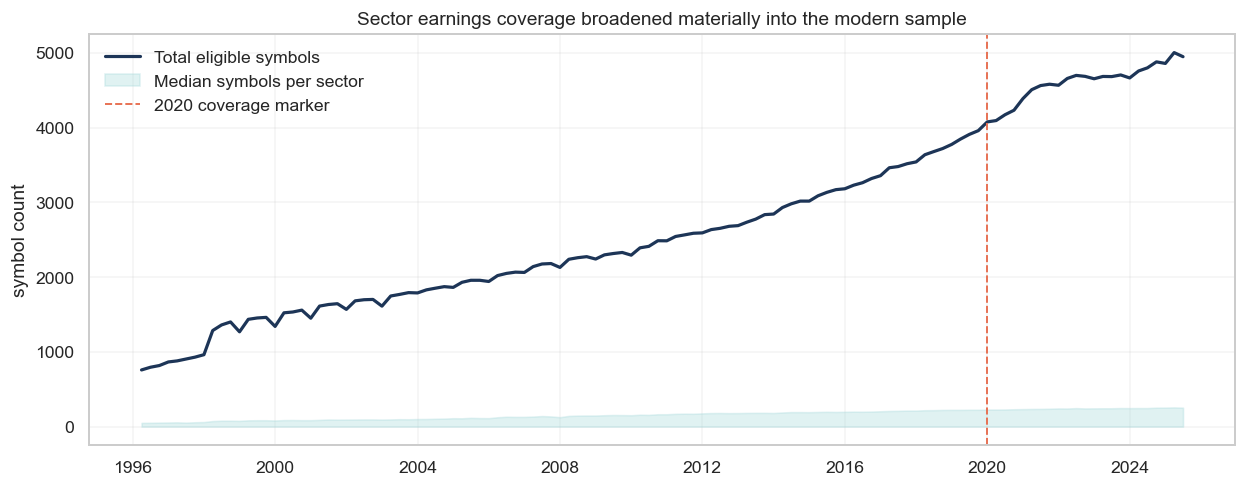

Filtered incomplete trailing quarters: ['2025Q3']


In [6]:
coverage = (
    pd.read_csv(ANALYSIS_DIR / 'sector_quarterly_surprise.csv')
    .groupby('fiscal_quarter')
    .agg(sectors=('sector', 'nunique'), total_symbols=('symbol_count', 'sum'), median_symbols=('symbol_count', 'median'))
    .reset_index()
)
coverage['quarter_end'] = pd.PeriodIndex(coverage['fiscal_quarter'], freq='Q').to_timestamp(how='end')
coverage['trailing_total_symbols'] = coverage['total_symbols'].rolling(4, min_periods=4).median().shift(1)
coverage['is_complete_quarter'] = coverage['trailing_total_symbols'].isna() | (
    coverage['total_symbols'] >= 0.50 * coverage['trailing_total_symbols']
)
incomplete_quarters = coverage.loc[~coverage['is_complete_quarter'], 'fiscal_quarter'].tolist()
coverage = coverage.loc[coverage['is_complete_quarter']].copy()
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(coverage['quarter_end'], coverage['total_symbols'], color='#1d3557', linewidth=2.0, label='Total eligible symbols')
ax.fill_between(coverage['quarter_end'], coverage['median_symbols'], color='#a8dadc', alpha=0.35, label='Median symbols per sector')
ax.axvline(pd.Timestamp('2020-01-01'), color='#e76f51', linestyle='--', linewidth=1.2, label='2020 coverage marker')
ax.set_title('Sector earnings coverage broadened materially into the modern sample')
ax.set_ylabel('symbol count')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()
print('Filtered incomplete trailing quarters:', incomplete_quarters)

## 3. Distribution repair after clipping

The raw surprise and EPS-growth fields contain pathological percentages when the estimate or prior-year EPS is near zero. The cleaned analyzer keeps those rows in the symbol output, but excludes tiny denominators and clips the usable series before sector aggregation.

In [17]:
distribution_table = pd.DataFrame({
    'series': ['surprise_pct_raw', 'surprise_pct_clean', 'quarterly_eps_yoy_pct_raw', 'quarterly_eps_yoy_pct_clean'],
    'p01': [
        quarterly_symbol['surprise_pct_raw'].quantile(0.01),
        quarterly_symbol['surprise_pct'].quantile(0.01),
        quarterly_symbol['quarterly_eps_yoy_pct_raw'].quantile(0.01),
        quarterly_symbol['quarterly_eps_yoy_pct'].quantile(0.01),
    ],
    'median': [
        quarterly_symbol['surprise_pct_raw'].median(),
        quarterly_symbol['surprise_pct'].median(),
        quarterly_symbol['quarterly_eps_yoy_pct_raw'].median(),
        quarterly_symbol['quarterly_eps_yoy_pct'].median(),
    ],
    'p99': [
        quarterly_symbol['surprise_pct_raw'].quantile(0.99),
        quarterly_symbol['surprise_pct'].quantile(0.99),
        quarterly_symbol['quarterly_eps_yoy_pct_raw'].quantile(0.99),
        quarterly_symbol['quarterly_eps_yoy_pct'].quantile(0.99),
    ],
}).round(2)
display(distribution_table)

clip_settings = pd.DataFrame(
    {
        'setting': ['lower_quantile', 'upper_quantile', 'min_abs_eps_base'],
        'value': [
            cleaning['outlier_controls']['lower_quantile'],
            cleaning['outlier_controls']['upper_quantile'],
            cleaning['outlier_controls']['min_abs_eps_base'],
        ],
    }
)
clip_series_meta = pd.DataFrame(
    {
        key: value
        for key, value in cleaning['outlier_controls'].items()
        if isinstance(value, dict)
    }
).T
display(clip_settings)
display(clip_series_meta)

,series,p01,median,p99
0,surprise_pct_raw,-893.86,3.57,550.00
1,surprise_pct_clean,-469.49,3.70,280.79
2,quarterly_eps_yoy_pct_raw,-1900.00,10.00,1487.93
3,quarterly_eps_yoy_pct_clean,-875.96,9.52,620.52


,setting,value
0,lower_quantile,0.01
1,upper_quantile,0.99
2,min_abs_eps_base,0.05


,eligible_rows,clipped_rows,lower_bound,upper_bound,low_base_rows
surprise_pct,227843.0,4558.0,-469.676936,280.847148,35325.0
quarterly_eps_yoy_pct,272859.0,5458.0,-876.495100,620.541293,32946.0
annual_eps_yoy_pct,76828.0,1538.0,-1036.559124,826.548300,2524.0


## 4. Cleaned sector relationship map

Once the ambiguous buckets are removed, the sector correlation tables become much more interpretable. This section uses the cleaned cap-weighted surprise series rather than the raw universe.

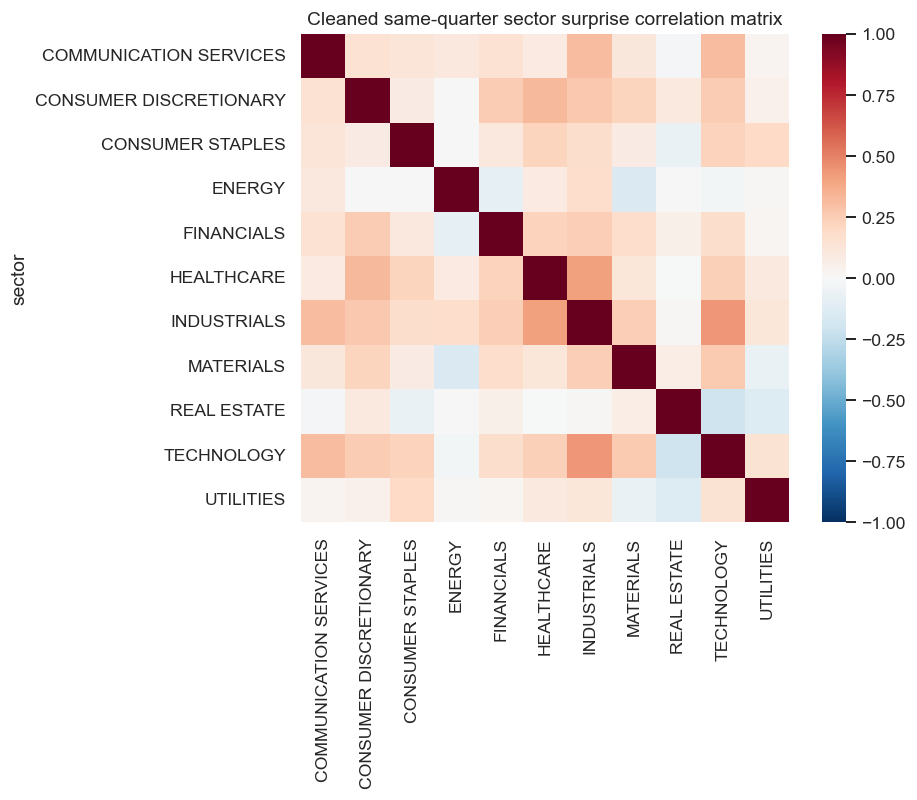

,source_sector,target_sector,relationship,correlation,overlap_quarters,abs_correlation
0,INDUSTRIALS,TECHNOLOGY,same_quarter,0.438542,119,0.438542
1,HEALTHCARE,INDUSTRIALS,same_quarter,0.407395,119,0.407395
2,CONSUMER DISCRETIONARY,HEALTHCARE,same_quarter,0.321070,119,0.321070
3,COMMUNICATION SERVICES,INDUSTRIALS,same_quarter,0.310036,119,0.310036
4,COMMUNICATION SERVICES,TECHNOLOGY,same_quarter,0.304799,119,0.304799
5,CONSUMER DISCRETIONARY,INDUSTRIALS,same_quarter,0.269785,119,0.269785
6,MATERIALS,TECHNOLOGY,same_quarter,0.263331,119,0.263331
7,CONSUMER DISCRETIONARY,FINANCIALS,same_quarter,0.256339,119,0.256339
8,CONSUMER DISCRETIONARY,TECHNOLOGY,same_quarter,0.252146,119,0.252146
9,FINANCIALS,INDUSTRIALS,same_quarter,0.247744,119,0.247744


,source_sector,target_sector,relationship,correlation,overlap_quarters,abs_correlation
0,INDUSTRIALS,TECHNOLOGY,source_surprise_leads_target_by_1q,0.386660,118,0.386660
1,TECHNOLOGY,INDUSTRIALS,source_surprise_lags_target_by_1q,0.386660,118,0.386660
2,INDUSTRIALS,TECHNOLOGY,source_surprise_lags_target_by_1q,0.325765,118,0.325765
3,TECHNOLOGY,INDUSTRIALS,source_surprise_leads_target_by_1q,0.325765,118,0.325765
4,COMMUNICATION SERVICES,INDUSTRIALS,source_surprise_lags_target_by_1q,0.306948,118,0.306948
5,INDUSTRIALS,COMMUNICATION SERVICES,source_surprise_leads_target_by_1q,0.306948,118,0.306948
6,CONSUMER DISCRETIONARY,TECHNOLOGY,source_surprise_lags_target_by_1q,0.274292,118,0.274292
7,TECHNOLOGY,CONSUMER DISCRETIONARY,source_surprise_leads_target_by_1q,0.274292,118,0.274292
8,INDUSTRIALS,HEALTHCARE,source_surprise_leads_target_by_1q,0.258001,118,0.258001
9,HEALTHCARE,INDUSTRIALS,source_surprise_lags_target_by_1q,0.258001,118,0.258001


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 7.0))
sns.heatmap(sector_corr, cmap='RdBu_r', center=0.0, vmin=-1.0, vmax=1.0, square=True, ax=ax)
ax.set_title('Cleaned same-quarter sector surprise correlation matrix')
plt.tight_layout()
plt.show()

display(sector_surprise_pairs.head(12))
display(sector_lead_lag.head(12))

## 5. Sector market-cap and liquidity structure

The panel adds a time-varying size and liquidity layer by scaling current market cap with each symbol's monthly adjusted-price path and aggregating monthly dollar volume into sector-quarter turnover proxies. This is still an approximation because share counts are not point-in-time, but it is materially better than a static 2025 snapshot.

,sector,market_cap_share,turnover_proxy,market_cap_proxy_total
939,TECHNOLOGY,0.294461,0.367659,2.563600e+13
469,FINANCIALS,0.156912,0.263041,1.366087e+13
93,COMMUNICATION SERVICES,0.123266,0.237107,1.073159e+13
187,CONSUMER DISCRETIONARY,0.103978,0.522778,9.052405e+12
563,HEALTHCARE,0.091649,0.368963,7.979013e+12
657,INDUSTRIALS,0.074112,0.422421,6.452283e+12
281,CONSUMER STAPLES,0.048478,0.294483,4.220529e+12
375,ENERGY,0.040219,0.267959,3.501473e+12
751,MATERIALS,0.026943,0.367521,2.345691e+12
1033,UTILITIES,0.021130,0.315200,1.839553e+12


The raw table uses level proxies; the charts below switch to cross-sectional ranks because they are more stable than absolute proxy levels across time.


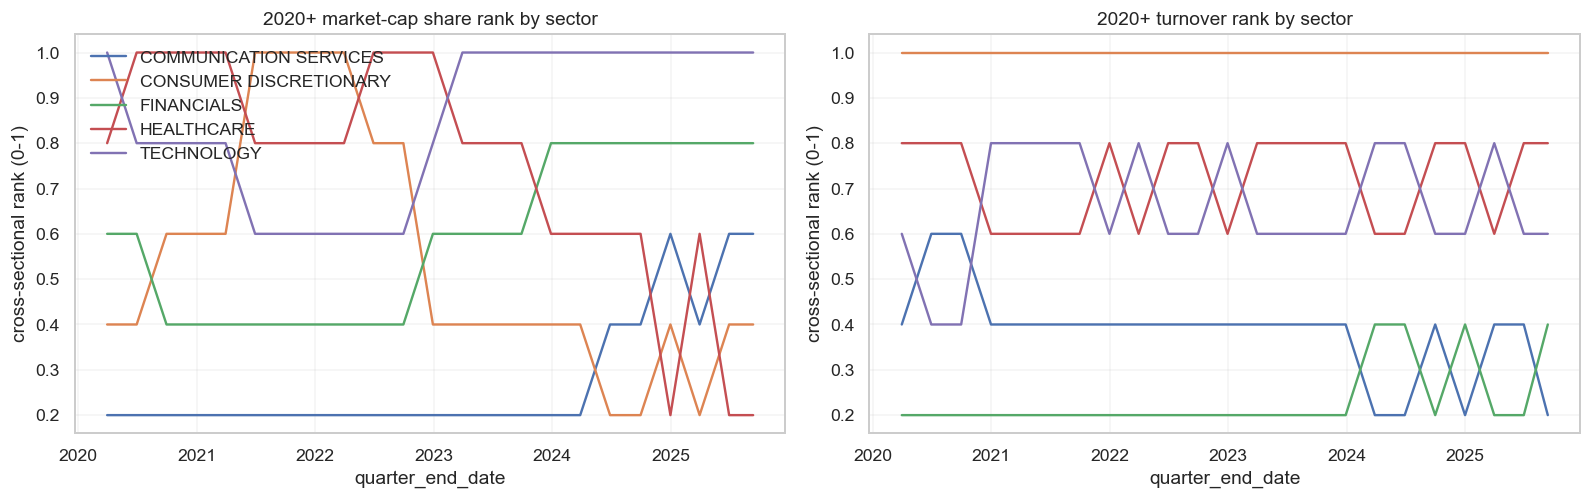

In [11]:
market_structure['quarter_end_date'] = pd.to_datetime(market_structure['quarter_end_date'])
latest_quarter = market_structure['fiscal_quarter'].max()
latest_structure = market_structure.loc[market_structure['fiscal_quarter'] == latest_quarter].copy()
latest_structure = latest_structure.sort_values('market_cap_share', ascending=False)
display(latest_structure[['sector', 'market_cap_share', 'turnover_proxy', 'market_cap_proxy_total']].head(11))

print('The raw table uses level proxies; the charts below switch to cross-sectional ranks because they are more stable than absolute proxy levels across time.')
top_sectors = latest_structure.head(5)['sector'].tolist()
plot_frame = market_structure.loc[
    (market_structure['sector'].isin(top_sectors)) & (market_structure['quarter_end_date'] >= '2020-01-01')
].copy()
plot_frame['market_cap_share_rank'] = plot_frame.groupby('quarter_end_date')['market_cap_share'].rank(pct=True)
plot_frame['turnover_proxy_rank'] = plot_frame.groupby('quarter_end_date')['turnover_proxy'].rank(pct=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=plot_frame, x='quarter_end_date', y='market_cap_share_rank', hue='sector', ax=axes[0])
axes[0].set_title('2020+ market-cap share rank by sector')
axes[0].set_ylabel('cross-sectional rank (0-1)')
axes[0].legend(frameon=False, loc='upper left')
sns.lineplot(data=plot_frame, x='quarter_end_date', y='turnover_proxy_rank', hue='sector', ax=axes[1])
axes[1].set_title('2020+ turnover rank by sector')
axes[1].set_ylabel('cross-sectional rank (0-1)')
axes[1].legend_.remove()
plt.tight_layout()
plt.show()

## 6. Panel design and target definition

The target is **next-quarter sector ETF excess return vs SPY**. Earnings features are lagged one quarter so the model only sees information that would have been known after the prior earnings season. Market-cap, liquidity, and ETF price-state features are measured at the current quarter-end.

,metric,value
0,panel rows,888
1,quarters,91
2,sectors,11
3,features,55
4,post-2020 rows,253
5,holdout rows,33


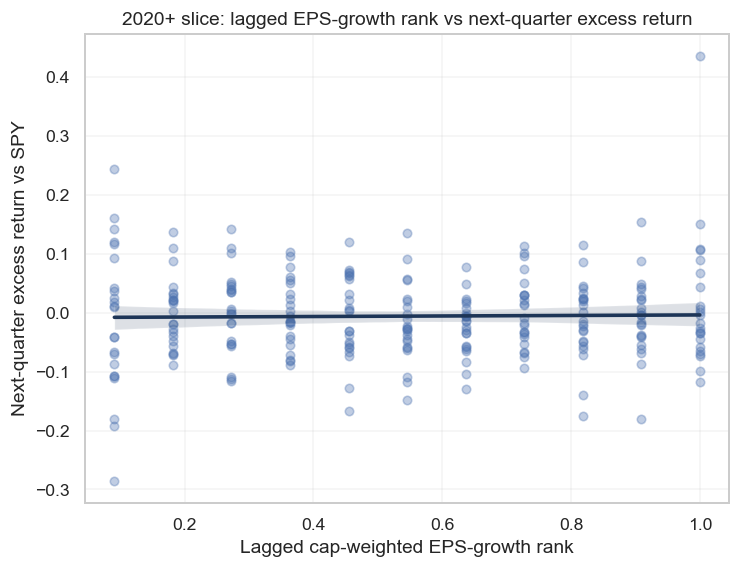

In [12]:
panel['quarter_end_date'] = pd.to_datetime(panel['quarter_end_date'])
panel['post_2020'] = panel['fiscal_quarter'] >= '2020Q1'
panel_snapshot = pd.DataFrame({
    'metric': ['panel rows', 'quarters', 'sectors', 'features', 'post-2020 rows', 'holdout rows'],
    'value': [
        research_summary['panel_rows'],
        research_summary['quarter_count'],
        research_summary['sector_count'],
        research_summary['feature_count'],
        int(panel['post_2020'].sum()),
        int(research_summary['holdout_ensemble_metrics'].get('observations', 0)),
    ],
})
display(panel_snapshot)

recent = panel.loc[panel['fiscal_quarter'] >= '2020Q1'].copy()
fig, ax = plt.subplots(figsize=(6.6, 5.1))
sns.regplot(
    data=recent,
    x='cap_weighted_quarterly_eps_yoy_pct_lag1_rank',
    y='target_excess_return',
    scatter_kws={'alpha': 0.35, 's': 28},
    line_kws={'color': '#1d3557'},
    ax=ax,
)
ax.set_title('2020+ slice: lagged EPS-growth rank vs next-quarter excess return')
ax.set_xlabel('Lagged cap-weighted EPS-growth rank')
ax.set_ylabel('Next-quarter excess return vs SPY')
plt.tight_layout()
plt.show()

## 7. Ensemble model results

The point of the model layer is not to manufacture a heroic backtest. It is to test whether the cleaned sector earnings factors still carry signal after controlling for size, liquidity, and ETF price state. Read the holdout carefully: it is only three completed quarters in the current export.

,scope,model_label,observations,target_rate,brier_score,accuracy,precision,recall,roc_auc
0,validation,Elastic Net,675,0.485926,0.287651,0.496296,0.479021,0.417683,0.488806
1,validation,ExtraTrees,675,0.485926,0.252450,0.485926,0.469649,0.448171,0.487928
2,validation,LightGBM,675,0.485926,0.270057,0.493333,0.478916,0.484756,0.492470
3,validation,Average Ensemble,675,0.485926,0.261113,0.488889,0.473016,0.454268,0.485828
4,holdout,Elastic Net,33,0.212121,0.232003,0.606061,0.312500,0.714286,0.664835
5,holdout,ExtraTrees,33,0.212121,0.241941,0.545455,0.277778,0.714286,0.714286
6,holdout,LightGBM,33,0.212121,0.242266,0.636364,0.352941,0.857143,0.675824
7,holdout,Average Ensemble,33,0.212121,0.234381,0.575758,0.266667,0.571429,0.681319


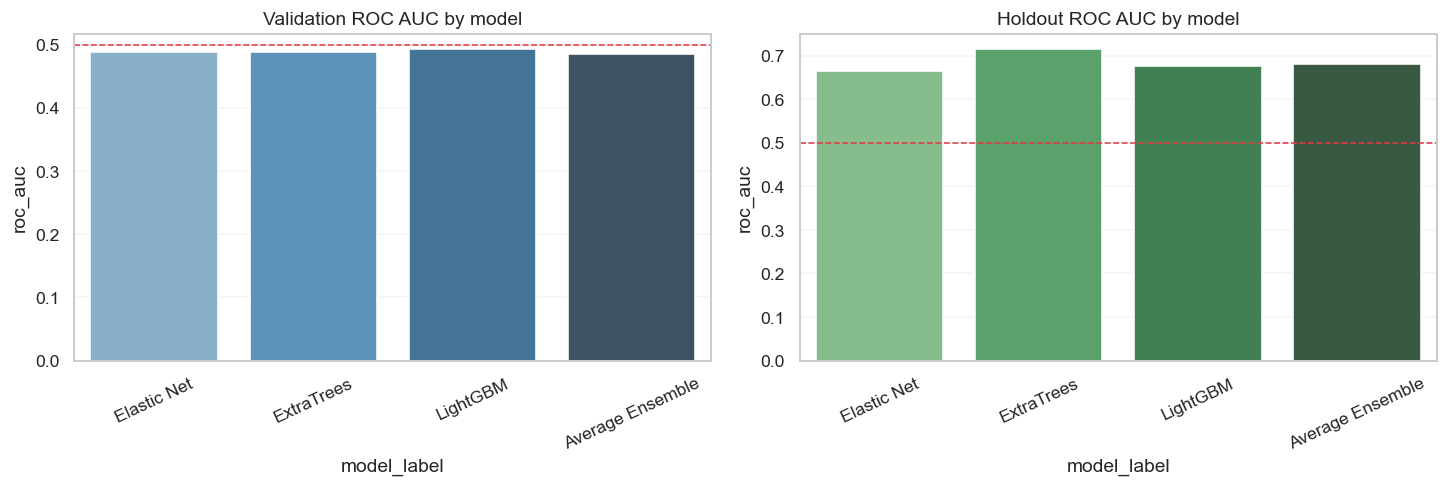

In [18]:
display(metrics)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4), sharey=False)
val = metrics.loc[metrics['scope'] == 'validation'].copy()
hold = metrics.loc[metrics['scope'] == 'holdout'].copy()
sns.barplot(data=val, x='model_label', y='roc_auc', hue='model_label', legend=False, ax=axes[0], palette='Blues_d')
axes[0].axhline(0.5, color='#e63946', linestyle='--', linewidth=1.0)
axes[0].set_title('Validation ROC AUC by model')
axes[0].tick_params(axis='x', rotation=25)
sns.barplot(data=hold, x='model_label', y='roc_auc', hue='model_label', legend=False, ax=axes[1], palette='Greens_d')
axes[1].axhline(0.5, color='#e63946', linestyle='--', linewidth=1.0)
axes[1].set_title('Holdout ROC AUC by model')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

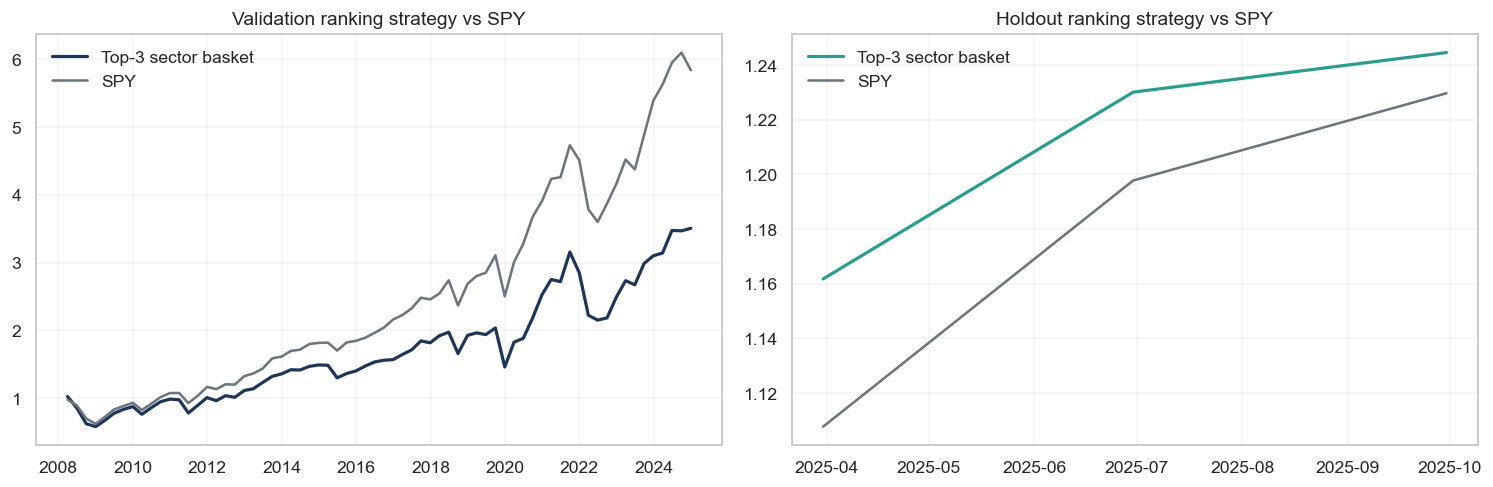

,scope,periods,total_return,cagr,sharpe,max_drawdown,hit_rate,avg_excess_return
0,validation,68,2.504787,0.076562,0.470547,-0.435124,0.441176,-0.005647
1,holdout,3,0.244519,0.338656,2.471777,0.000000,0.333333,0.005557


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4))
axes[0].plot(validation_strategy['quarter_end_date'], validation_strategy['portfolio_equity'], label='Top-3 sector basket', color='#1d3557', linewidth=2.0)
axes[0].plot(validation_strategy['quarter_end_date'], validation_strategy['spy_equity'], label='SPY', color='#6c757d', linewidth=1.6)
axes[0].set_title('Validation ranking strategy vs SPY')
axes[0].legend(frameon=False)
axes[1].plot(holdout_strategy['quarter_end_date'], holdout_strategy['portfolio_equity'], label='Top-3 sector basket', color='#2a9d8f', linewidth=2.0)
axes[1].plot(holdout_strategy['quarter_end_date'], holdout_strategy['spy_equity'], label='SPY', color='#6c757d', linewidth=1.6)
axes[1].set_title('Holdout ranking strategy vs SPY')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

strategy_table = pd.DataFrame([
    {'scope': 'validation', **research_summary['validation_strategy']},
    {'scope': 'holdout', **research_summary['holdout_strategy']},
])
display(strategy_table)

## 8. Feature importance and relationship takeaways

The strongest average features are a blend of liquidity, lagged breadth/beat-rate, EPS-growth ranks, and price-state variables. In other words: cleaned earnings matter, but they matter alongside market structure and momentum rather than in isolation.

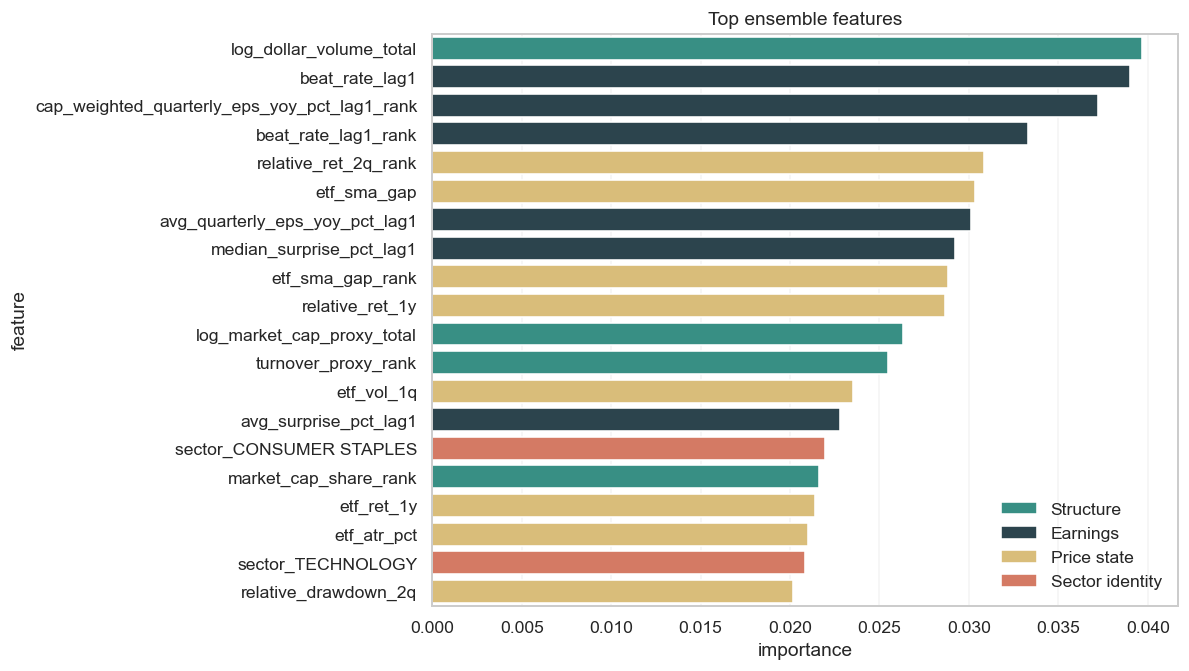

,feature,bucket,importance
0,log_dollar_volume_total,Structure,0.039686
1,beat_rate_lag1,Earnings,0.038993
2,cap_weighted_quarterly_eps_yoy_pct_lag1_rank,Earnings,0.037226
3,beat_rate_lag1_rank,Earnings,0.033325
4,relative_ret_2q_rank,Price state,0.030863
5,etf_sma_gap,Price state,0.030319
6,avg_quarterly_eps_yoy_pct_lag1,Earnings,0.030141
7,median_surprise_pct_lag1,Earnings,0.029208
8,etf_sma_gap_rank,Price state,0.028821
9,relative_ret_1y,Price state,0.028665


In [15]:
ensemble_features = (
    feature_importance.loc[feature_importance['model_label'] == 'Average Ensemble']
    .sort_values('importance', ascending=False)
    .head(20)
    .copy()
)
def feature_bucket(name: str) -> str:
    if 'surprise' in name or 'eps' in name or 'beat_rate' in name or 'reported_eps' in name or 'estimated_eps' in name:
        return 'Earnings'
    if 'market_cap' in name or 'turnover' in name or 'dollar_volume' in name:
        return 'Structure'
    if name.startswith('sector_'):
        return 'Sector identity'
    return 'Price state'
ensemble_features['bucket'] = ensemble_features['feature'].map(feature_bucket)
palette = {'Earnings': '#264653', 'Structure': '#2a9d8f', 'Price state': '#e9c46a', 'Sector identity': '#e76f51'}
fig, ax = plt.subplots(figsize=(10.5, 6.0))
sns.barplot(
    data=ensemble_features,
    x='importance',
    y='feature',
    hue='bucket',
    dodge=False,
    palette=palette,
    ax=ax,
)
ax.set_title('Top ensemble features')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()
display(ensemble_features[['feature', 'bucket', 'importance']])

## 9. Holdout quarter picks

The live relevance of the model is in the most recent completed quarters. This is a tiny sample, so the table below should be read as a case study rather than proof of a durable edge.

In [16]:
holdout_latest = holdout_predictions.sort_values(['fiscal_quarter', 'ensemble_probability'], ascending=[True, False]).copy()
display(holdout_strategy)
display(holdout_latest[['fiscal_quarter', 'sector', 'etf_symbol', 'ensemble_probability', 'target_excess_return']].head(15))

,fiscal_quarter,quarter_end_date,selected_sectors,selected_etfs,portfolio_return,spy_return,excess_return,avg_probability,portfolio_equity,spy_equity,alpha_equity
0,2025Q1,2025-03-31,"TECHNOLOGY, INDUSTRIALS, COMMUNICATION SERVICES","XLK, XLI, XLC",0.161785,0.107772,0.054013,0.580255,1.161785,1.107772,1.054013
1,2025Q2,2025-06-30,"FINANCIALS, COMMUNICATION SERVICES, INDUSTRIALS","XLF, XLC, XLI",0.058768,0.081212,-0.022444,0.561626,1.230060,1.197736,1.030356
2,2025Q3,2025-09-30,"FINANCIALS, MATERIALS, COMMUNICATION SERVICES","XLF, XLB, XLC",0.011755,0.026652,-0.014897,0.547238,1.244519,1.229658,1.015007


,fiscal_quarter,sector,etf_symbol,ensemble_probability,target_excess_return
9,2025Q1,TECHNOLOGY,XLK,0.623138,0.120675
6,2025Q1,INDUSTRIALS,XLI,0.563716,0.021159
0,2025Q1,COMMUNICATION SERVICES,XLC,0.553911,0.020205
1,2025Q1,CONSUMER DISCRETIONARY,XLY,0.500256,-0.004804
3,2025Q1,ENERGY,XLE,0.477231,-0.192845
4,2025Q1,FINANCIALS,XLF,0.470044,-0.052773
5,2025Q1,HEALTHCARE,XLV,0.463807,-0.180209
8,2025Q1,REAL ESTATE,XLRE,0.446105,-0.109094
7,2025Q1,MATERIALS,XLB,0.441244,-0.081286
2,2025Q1,CONSUMER STAPLES,XLP,0.393737,-0.109542


## 10. Conclusions and caveats

**What the cleaned research supports**
- The sector cleanup was worth doing. The relationship tables become much more coherent once `UNKNOWN`, `OTHER`, and non-primary securities are removed from aggregate sector statistics.
- Earnings information still shows up in the model after the cleanup, especially lagged beat-rate and lagged EPS-growth ranks.
- Liquidity, market-cap share, and ETF price state are just as important as the earnings fields, which argues against reading sector leadership through fundamentals alone.
- The post-2020 slice is the richest part of the dataset by breadth and therefore the most credible place to stress-test any sector earnings thesis.

**What the cleaned research does not support yet**
- A strong, repeatable outperformance claim from the current average ensemble. Validation ROC AUC is near random and the validation top-3 basket does not beat SPY on average excess return.
- Over-interpretation of the 2025 holdout. The current holdout export covers only three completed quarters, so the better holdout AUC can easily be noise.
- A truly point-in-time historical market-cap panel. The size layer uses a price-scaled proxy because historical share counts are not available in the current cache.

**Natural next upgrades**
1. Re-index sector earnings by reported-date windows instead of conservative quarter lags once a release-aware sector panel is available.
2. Add true point-in-time share counts or shares-outstanding histories so sector size is not approximated from current market cap.
3. Test cross-sectional targets such as next-quarter top-third sector rank, not just ETF excess return vs SPY.